In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
%matplotlib inline

In [17]:
file_path = "creditcard.csv"
df = pd.read_csv(file_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
df.shape

(284807, 31)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [20]:
X = df.drop(['Class'], axis=1)
y = df['Class']
X = StandardScaler().fit_transform(X)

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

In [22]:
X_train = torch.tensor(X_train, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)

X_test = torch.tensor(X_test, dtype = torch.float32)
y_test = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [23]:
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 128
train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


In [24]:
class CreditCardFraudMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.ll1 = nn.Linear(30,128)
        self.ll2 = nn.Linear(128,64)
        self.ll3 = nn.Linear(64,32)

        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(32)

        self.op = nn.Linear(32,1)

    def forward(self, x):
        x = self.ll1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.ll2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.ll3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.op(x)
        return x
    
model = CreditCardFraudMLP()
print(model)

CreditCardFraudMLP(
  (ll1): Linear(in_features=30, out_features=128, bias=True)
  (ll2): Linear(in_features=128, out_features=64, bias=True)
  (ll3): Linear(in_features=64, out_features=32, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (op): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
weights = torch.tensor([500.0]) 
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=weights)
optimizier = torch.optim.Adam(model.parameters(), lr = 0.001)

In [13]:
epochs = 20

train_losses=[]
test_losses=[]

for epoch in range(epochs):
    
    #training
    model.train()
    train_bl = []
    for X_batch, y_batch in train_l:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        optimizier.zero_grad()
        loss.backward()
        optimizier.step()
        train_bl.append(loss.item())
    train_losses.append(np.mean(train_bl))

    #testing
    model.eval()
    test_bl=[]
    with torch.no_grad():
        for X_batch, y_batch in test_l:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            test_bl.append(loss.item())
        test_losses.append(np.mean(test_bl))
    
    if(epoch+1)%5==0:
        print(f"Epoch: {epoch+1:2d}/{epochs} | Train loss: {train_losses[-1]:.4f} | Test loss: {test_losses[-1]:.4f}")  

Epoch:  5/20 | Train loss: 0.0286 | Test loss: 1.8057
Epoch: 10/20 | Train loss: 0.0262 | Test loss: 1.6820
Epoch: 15/20 | Train loss: 0.0191 | Test loss: 1.5789
Epoch: 20/20 | Train loss: 0.0425 | Test loss: 1.7111


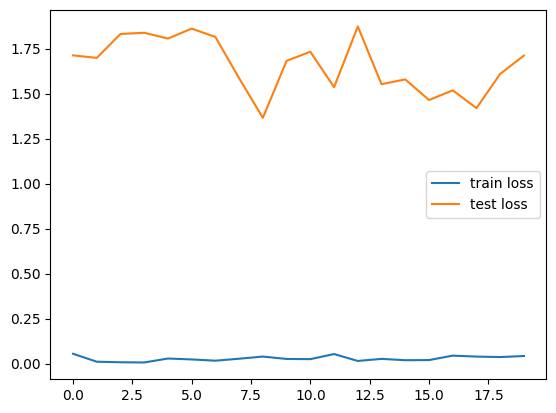

In [15]:
plt.plot(train_losses, label = "train loss")
plt.plot(test_losses, label = "test loss")
plt.legend()

We have high test loss, as we used the 500 pos_weight, so to prove we are actually catching frauds lets build a confusion matrix:

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    prob = torch.sigmoid(test_pred)
    test_pred_binary = (prob>=0.5).float()

print(confusion_matrix(y_test, test_pred_binary))
print(classification_report(y_test, test_pred_binary))

[[70559   530]
 [   14    99]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     71089
         1.0       0.16      0.88      0.27       113

    accuracy                           0.99     71202
   macro avg       0.58      0.93      0.63     71202
weighted avg       1.00      0.99      1.00     71202



Here recall is good, that means, from the 113 actual frauds, the model caught 99, which is good.

But at the same time precision is bad, as from the 71089 non frauds, the model flagged 530 as fraud, so probability of flagging a non fraud as fraud is more than probability of flagging actual fraud as fraud

This is precision-recall tradeoff, and dealing with it depends on what the model is needed for

If safety is more important then keep it like this with 500 pos_weight, and therefore the model even tho flags non frauds as frauds, it also catches actual frauds well.

If precision is more important then 200 pos_weight is good, as it wont flag many non frauds as fraud